In [85]:
import pandas as pd
from pprint import pprint
#filter to only the rows where the model is resnet50
# gb = cc.groupby(["backbone", "pooling", "sampler", "weight_config", "fulltune"])
coralcam_groups = ['aggression', 'biting']
fishfollow_groups = ['habitat', 'movement', 'bites', 'social_interaction', 'not_visible']

cc = pd.concat([pd.read_csv("../results/eccv/coralcam_eccv_label_tolerance_7.csv"), 
                pd.read_csv("../results/new_grouping/coralcam_results_label_tolerance_7.csv")], ignore_index=True)

ff = pd.concat([pd.read_csv("../results/eccv/fishfollow_eccv_label_tolerance_7.csv"), 
                pd.read_csv("../results/new_grouping/fishfollow_results_label_tolerance_7.csv")], ignore_index=True)

# drop rows where model is vjepa2
cc = cc[cc["backbone"] != "vjepa2"]
ff = ff[ff["backbone"] != "vjepa2"]

In [86]:
# Load YAML
import yaml

with open("flops.yaml", "r") as f:
    data = yaml.safe_load(f)

# Convert to DataFrame
flops = pd.DataFrame(data)

In [87]:
def preprocess(df): 
    #drop rows where weight_config is empty or Nan or any other value that indicates no weights were used
    df = df[df["weight_config"].notna() & (df["weight_config"] != "") & (df["weight_config"] != "none") & (df["weight_config"] != "no_weights")]
    #rename videomae to videomae_base
    return df

In [88]:
df = preprocess(cc)
dataset = "coralcam"
df[['dataset', 'backbone', 'pooling', 'sampler', 'weight_config', 'f1_macro']]

,dataset,backbone,pooling,sampler,weight_config,f1_macro
0,coralcam,dinov3_base,attention,balanced,{'weight_method': 'uniform'},0.309183
1,coralcam,dinov3_base,attention,balanced,"{'weight_method': 'focal_loss', 'focal_loss_al...",0.288791
2,coralcam,dinov3_base,mean,balanced,{'weight_method': 'uniform'},0.025878
3,coralcam,dinov3_base,mean,balanced,"{'weight_method': 'focal_loss', 'focal_loss_al...",0.241447
4,coralcam,videomae_large,attention,balanced,{'weight_method': 'uniform'},0.260826
5,coralcam,videomae_large,attention,balanced,"{'weight_method': 'focal_loss', 'focal_loss_al...",0.450383
6,coralcam,videomae_large,mean,balanced,{'weight_method': 'uniform'},0.243682
7,coralcam,videomae_large,mean,balanced,"{'weight_method': 'focal_loss', 'focal_loss_al...",0.230205
8,coralcam,dinov3_large,attention,balanced,weight_method='uniform',0.324976
9,coralcam,dinov3_large,attention,balanced,weight_method='focal_loss' focal_loss_gamma=5....,0.329175


In [89]:
flops_agg = (
    flops
    .groupby(["dataset", "backbone", "pooling" ], as_index=False)
    .agg({
        "flops": "mean"
    })
)
df_agg = (
    df
    .groupby(["dataset", "backbone", "pooling"], as_index=False)
    .agg({
        "f1_macro": "max"
    })
)
merged = pd.merge(df_agg, flops_agg, on=["dataset", "backbone", "pooling"], how="inner")
print(merged.columns)
merged["backbone"] = merged["backbone"].replace({"videomae": "videomae_base"})

merged[['backbone','pooling', 'f1_macro', 'flops']]

Index(['dataset', 'backbone', 'pooling', 'f1_macro', 'flops'], dtype='object')


,backbone,pooling,f1_macro,flops
0,dinov3_base,attention,0.309183,1.744640e+10
1,dinov3_base,mean,0.241447,1.720703e+10
2,dinov3_large,attention,0.329175,6.132993e+10
3,dinov3_large,mean,0.237616,6.090486e+10
4,resnet50,attention,0.285857,4.530088e+09
5,resnet50,mean,0.249886,4.109955e+09
6,videomae_base,attention,0.362011,1.370373e+11
7,videomae_base,mean,0.192891,1.351780e+11
8,videomae_large,attention,0.450383,4.796818e+11
9,videomae_large,mean,0.243682,4.763801e+11


In [90]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_flops(df, pooling_type=None, destination: str = None):
    fig, ax = plt.subplots(figsize=(8, 6))

    if pooling_type is not None:
        df = df[df["pooling"] == pooling_type]

    backbones = sorted(df["backbone"].unique())
    pooling_types = sorted(df["pooling"].unique())

    # Colors for pooling (trend line color)
    pooling_color_map = {
        "attention": "#1f77b4",  # blue
        "mean": "#d62728",       # red
    }

    # Shapes for backbone
    marker_cycle = ["o", "s", "^", "D", "P", "X"]
    backbone_marker_map = {
        backbone: marker_cycle[i % len(marker_cycle)]
        for i, backbone in enumerate(backbones)
    }

    # -------- Plot Points --------
    for backbone in backbones:
        for pooling in pooling_types:
            subset = df[
                (df["backbone"] == backbone) &
                (df["pooling"] == pooling)
            ]

            if subset.empty:
                continue

            x = subset["flops"]
            y = subset["f1_macro"]

            ax.scatter(
                x,
                y,
                color=pooling_color_map[pooling],
                marker=backbone_marker_map[backbone],
                s=130,
                edgecolor="black",
                linewidth=0.8,
                zorder=3
            )

    # -------- Trend Lines (per pooling type) --------
    for pooling in pooling_types:
        subset = df[df["pooling"] == pooling].sort_values("flops")

        if subset.empty:
            continue

        ax.plot(
            subset["flops"],
            subset["f1_macro"],
            color=pooling_color_map[pooling],
            linewidth=2.5,
            alpha=0.8,
            zorder=2
        )

    ax.set_xscale("log")
    ax.set_xlabel("FLOPs (log scale)")
    ax.set_ylabel("F1 Macro")
    ax.set_title("Performance vs Compute")

    # -------- Legends --------

    # Backbone legend (shapes)
    backbone_handles = [
        Line2D(
            [0], [0],
            marker=backbone_marker_map[b],
            color='gray',
            linestyle='None',
            markerfacecolor='gray',
            markeredgecolor='black',
            markersize=9,
            label=b
        )
        for b in backbones
    ]

    # Pooling legend (colors / lines)
    pooling_handles = [
        Line2D(
            [0], [0],
            color=pooling_color_map[p],
            linewidth=2.5,
            label=p
        )
        for p in pooling_types
    ]

    # Put both legends in top-left without overlapping too much
    legend1 = ax.legend(
        handles=backbone_handles,
        title="Backbone (Shape)",
        loc="upper left"
    )
    ax.add_artist(legend1)

    ax.legend(
        handles=pooling_handles,
        title="Pooling (Color)",
        loc="upper left",
        bbox_to_anchor=(0, 0.6)
    )

    plt.tight_layout()
    plt.show()
    if destination is not None:
        fig.savefig(destination, bbox_inches="tight", dpi=300)

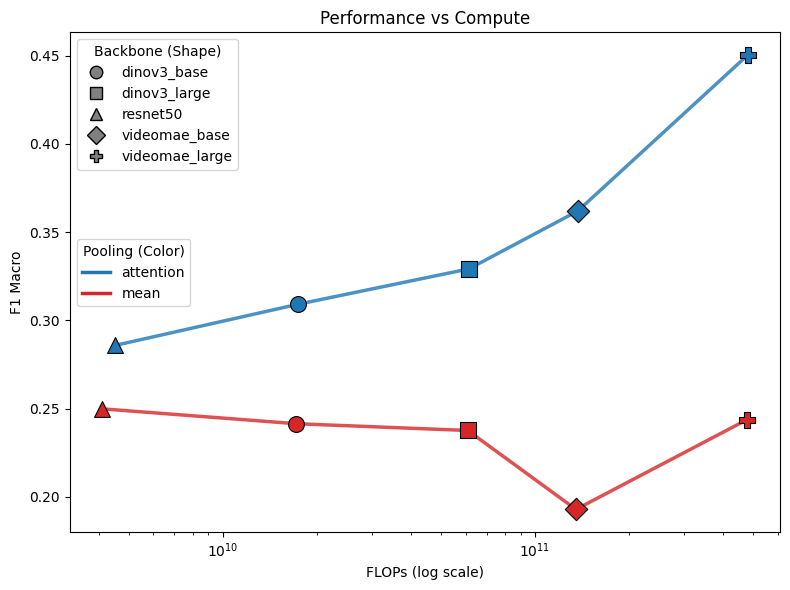

In [91]:
plot_flops(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "flops": "first"   # or "max" if flops varies slightly
        }).reset_index(), destination=f"{dataset}_performance_vs_compute.pdf")

In [92]:
with open("parameters.yaml", "r") as f:
    data = yaml.safe_load(f)

# Convert to DataFrame
parameters = pd.DataFrame(data)


In [93]:
params_agg = (
    parameters
    .groupby(["dataset", "backbone", "pooling" ], as_index=False)
    .agg({
        "parameters": "mean"
    })
)
df_agg = (
    df
    .groupby(["dataset", "backbone", "pooling"], as_index=False)
    .agg({
        "f1_macro": "max"
    })
)
merged = pd.merge(df_agg, params_agg, on=["dataset", "backbone", "pooling"], how="inner")
merged["backbone"] = merged["backbone"].replace({"videomae": "videomae_base"})

print(merged.columns)
merged[['backbone','pooling', 'f1_macro', 'parameters']]

Index(['dataset', 'backbone', 'pooling', 'f1_macro', 'parameters'], dtype='object')


,backbone,pooling,f1_macro,parameters
0,dinov3_base,attention,0.309183,88289029.0
1,dinov3_base,mean,0.241447,85924357.0
2,dinov3_large,attention,0.329175,307660549.0
3,dinov3_large,mean,0.237616,303459077.0
4,resnet50,attention,0.285857,40891205.0
5,resnet50,mean,0.249886,24099653.0
6,videomae_base,attention,0.362011,88855813.0
7,videomae_base,mean,0.192891,86491141.0
8,videomae_large,attention,0.450383,308391685.0
9,videomae_large,mean,0.243682,304190213.0


In [94]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

image_models = [
    "resnet50",
    "dinov3_base",
    "dinov3_large"
]

video_models = [
    "videomae_base",
    "videomae_large"
]

def plot_params(df, pooling_type: str, destination: str = None, legend_loc: str = "upper left"):
    if pooling_type is None:
        raise ValueError("pooling_type must be specified (e.g. 'attention' or 'mean').")

    df = df[df["pooling"] == pooling_type]

    if df.empty:
        raise ValueError(f"No data found for pooling type '{pooling_type}'.")

    fig, ax = plt.subplots(figsize=(8, 6))

    backbones = sorted(df["backbone"].unique())

    # Marker shapes per backbone
    marker_cycle = ["o", "s", "^", "D", "P", "X"]
    backbone_marker_map = {
        backbone: marker_cycle[i % len(marker_cycle)]
        for i, backbone in enumerate(backbones)
    }

    # Helper: determine color
    def get_color(backbone):
        if backbone in image_models:
            return "#1f77b4"  # blue
        elif backbone in video_models:
            return "#d62728"  # red
        else:
            return "gray"

    # -------- Scatter points --------
    for backbone in backbones:
        subset = df[df["backbone"] == backbone].sort_values("parameters")
        if subset.empty:
            continue

        point_color = get_color(backbone)

        ax.scatter(
            subset["parameters"],
            subset["f1_macro"],
            color=point_color,
            marker=backbone_marker_map[backbone],
            s=130,
            edgecolor="black",
            linewidth=0.8,
            zorder=3
        )

    ax.set_xscale("log")
    ax.set_xlabel("Parameters (log scale)")
    ax.set_ylabel("F1 Macro")
    ax.set_title(f"Performance vs Model Size ({pooling_type})")

    # -------- Backbone legend (shape + color) --------
    backbone_handles = [
        Line2D(
            [0], [0],
            marker=backbone_marker_map[b],
            linestyle='None',
            markerfacecolor=get_color(b),
            markeredgecolor='black',
            markersize=9,
            label=b
        )
        for b in backbones
    ]

    legend1 = ax.legend(
        handles=backbone_handles,
        title="Backbone",
        loc=legend_loc
    )
    ax.add_artist(legend1)

    # -------- Model type legend (color explanation) --------
    type_handles = [
        Line2D([0], [0],
               marker='o',
               linestyle='None',
               markerfacecolor="#1f77b4",
               markeredgecolor='black',
               markersize=9,
               label="Image Models"),
        Line2D([0], [0],
               marker='o',
               linestyle='None',
               markerfacecolor="#d62728",
               markeredgecolor='black',
               markersize=9,
               label="Video Models"),
    ]

    ax.legend(
        handles=type_handles,
        title="Model Type",
        loc="lower right"
    )

    fig.tight_layout()

    if destination is not None:
        fig.savefig(destination, bbox_inches="tight", dpi=300)

    plt.show()

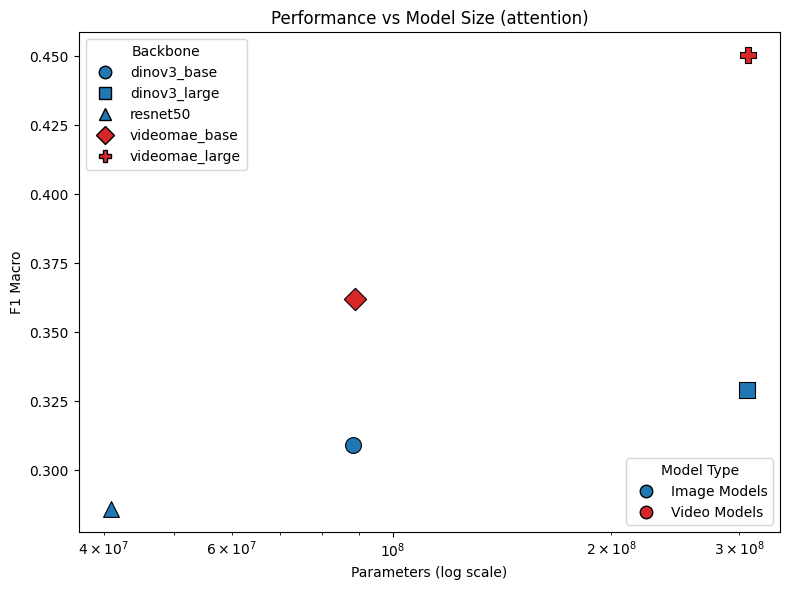

In [95]:
plot_params(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "parameters": "first"   # or "max" if params varies slightly
        }).reset_index(), pooling_type="attention", destination=f"{dataset}_performance_vs_params_attention.pdf")


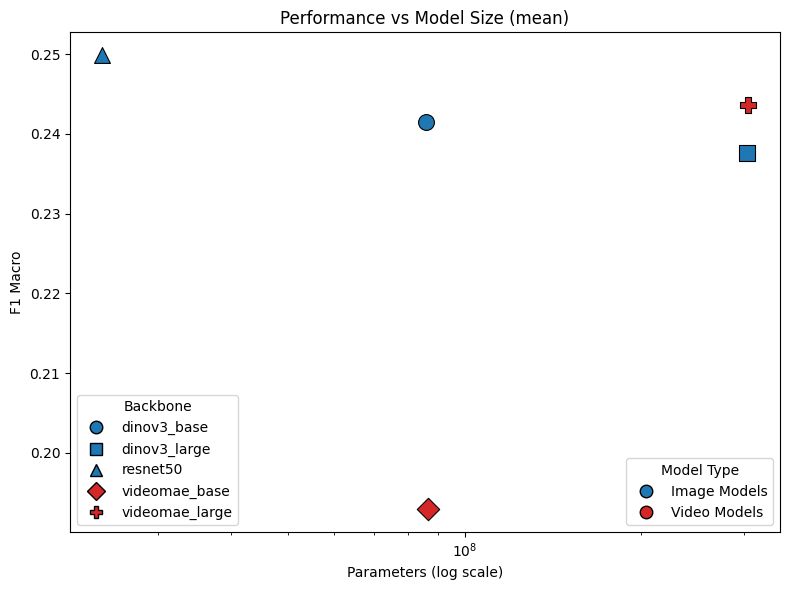

In [96]:
plot_params(merged.groupby(["backbone", "pooling"]).agg({
            "f1_macro": "max",
            "parameters": "first"   # or "max" if params varies slightly
        }).reset_index(), pooling_type="mean", legend_loc = "lower left")